<a href="https://colab.research.google.com/github/CHENNURUHARISH/PLANT-LEAF-DISEASE-DETECTION/blob/main/PLANT_DISEASE_PRE_VGG_16TRAINED_MODEL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 543ms/step - accuracy: 0.0642 - loss: 3.5665 - val_accuracy: 0.2456 - val_loss: 3.2988 - learning_rate: 1.0000e-04
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 65s 542ms/step - accuracy: 0.2391 - loss: 3.1791 - val_accuracy: 0.3408 - val_loss: 2.8208 - learning_rate: 1.0000e-04
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 547ms/step - accuracy: 0.3663 - loss: 2.7038 - val_accuracy: 0.4204 - val_loss: 2.4049 - learning_rate: 1.0000e-04
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 64s 533ms/step - accuracy: 0.4679 - loss: 2.2793 - val_accuracy: 0.4942 - val_loss: 2.0665 - learning_rate: 1.0000e-04
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 552ms/step - accuracy: 0.5212 - loss: 1.9528 - val_accuracy: 0.5101 - val_loss: 1.8494 - learning_rate: 1.0000e-04
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 64s 531ms/step - accuracy: 0.5496 - loss: 1.7263 - val_accuracy: 0.5475 - val_los

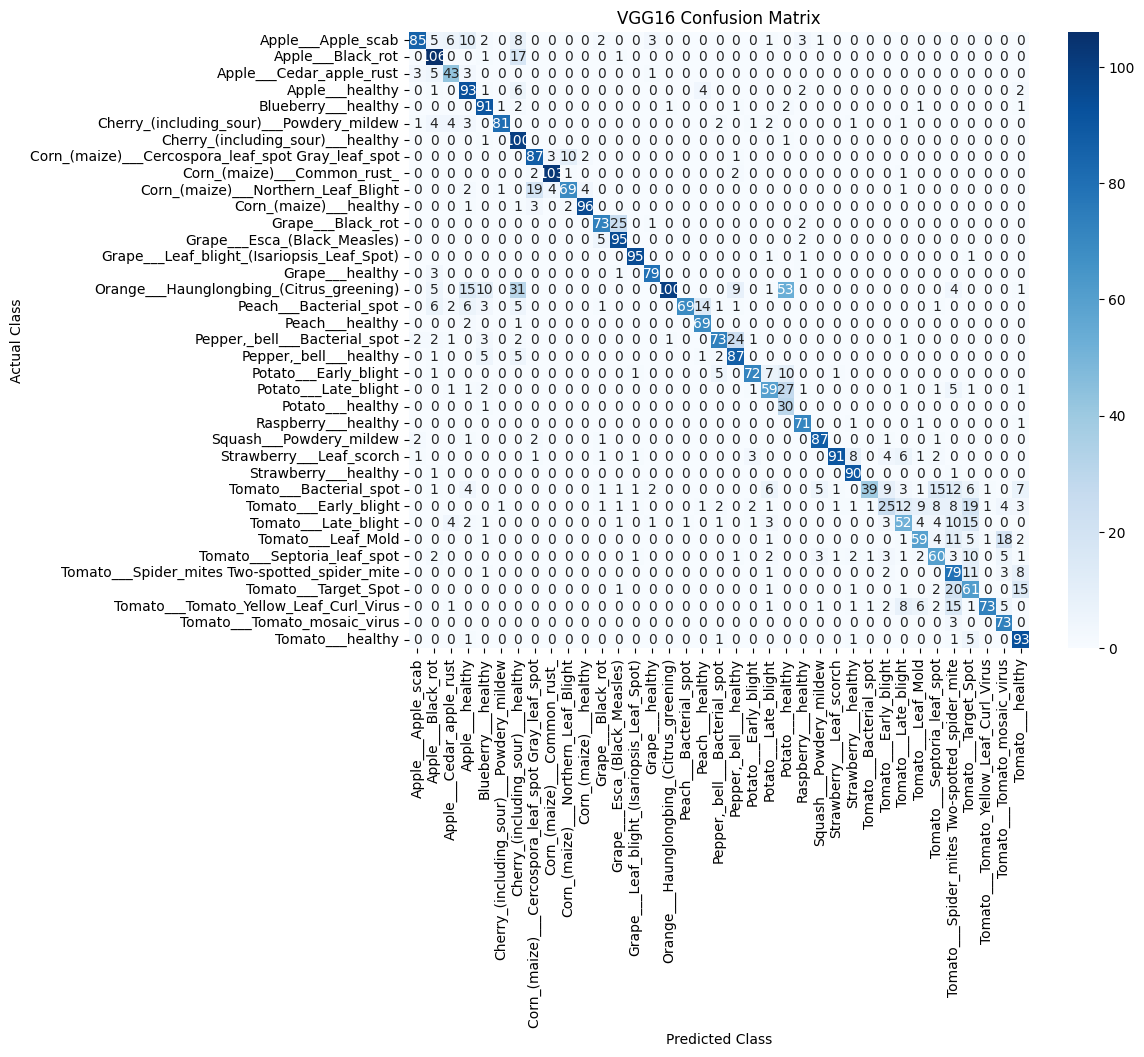

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),  #  VGG16 requires 224x224 input
    shuffle=True
)

# 🔹 Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# 🔹 Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# 🔹 Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])
normalization_layer = Rescaling(1.0 / 255)

# 🔹 Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 VGG16 Model
def build_vgg16_model(num_classes, input_shape=(224, 224, 3)):  # Fixed input shape
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# 🔹 Compile Model
vgg16_model = build_vgg16_model(num_classes)
vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 🔹 Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 🔹 Train Model
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=30, callbacks=[lr_scheduler, early_stopping])

# 🔹 Evaluate Model
val_loss, val_acc = vgg16_model.evaluate(valid_dataset)
print(f'VGG16 - Validation Accuracy: {val_acc:.4f}')

# 🔹 Confusion Matrix
y_pred = vgg16_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

cm_vgg16 = confusion_matrix(Y_true, predicted_categories)

# 🔹 Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('VGG16 Confusion Matrix')
plt.show()


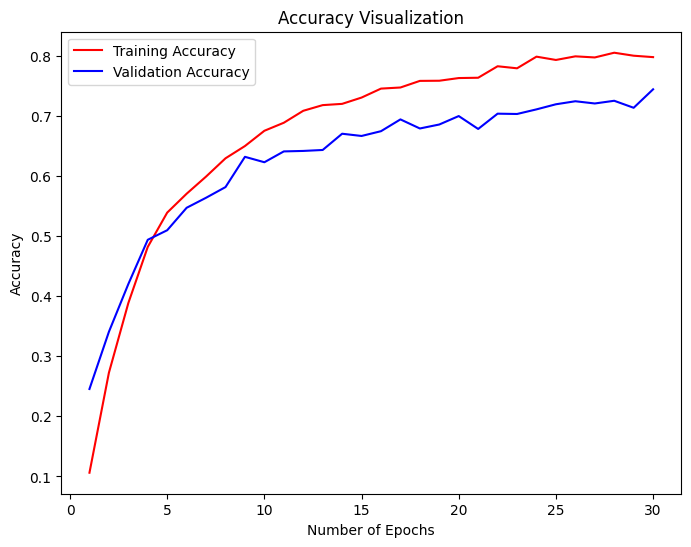

In [ ]:
# 🔹 Plot Accuracy Results
epochs = range(1, len(vgg16_history.history['accuracy']) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, vgg16_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, vgg16_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Visualization')
plt.legend()
plt.show()

In [ ]:
# 🔹 Evaluate Model
train_loss, train_acc = vgg16_model.evaluate(train_dataset)
print(f'VGG16 - Training Accuracy: {train_acc:.4f}')

120/120 ━━━━━━━━━━━━━━━━━━━━ 52s 431ms/step - accuracy: 0.7264 - loss: 0.9655
VGG16 - Training Accuracy: 0.7355


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 70s 561ms/step - accuracy: 0.0714 - loss: 3.5557 - val_accuracy: 0.2496 - val_loss: 3.2839 - learning_rate: 1.0000e-04
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 67s 557ms/step - accuracy: 0.2461 - loss: 3.1637 - val_accuracy: 0.3164 - val_loss: 2.8074 - learning_rate: 1.0000e-04
Epoch 3/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 549ms/step - accuracy: 0.3816 - loss: 2.6672 - val_accuracy: 0.3806 - val_loss: 2.4042 - learning_rate: 1.0000e-04
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 67s 558ms/step - accuracy: 0.4725 - loss: 2.2382 - val_accuracy: 0.4931 - val_loss: 2.0511 - learning_rate: 1.0000e-04
Epoch 5/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 65s 537ms/step - accuracy: 0.5080 - loss: 1.9610 - val_accuracy: 0.4931 - val_loss: 1.8608 - learning_rate: 1.0000e-04
Epoch 6/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 549ms/step - accuracy: 0.5427 - loss: 1.7128 - val_accuracy: 0.5528 - val_los

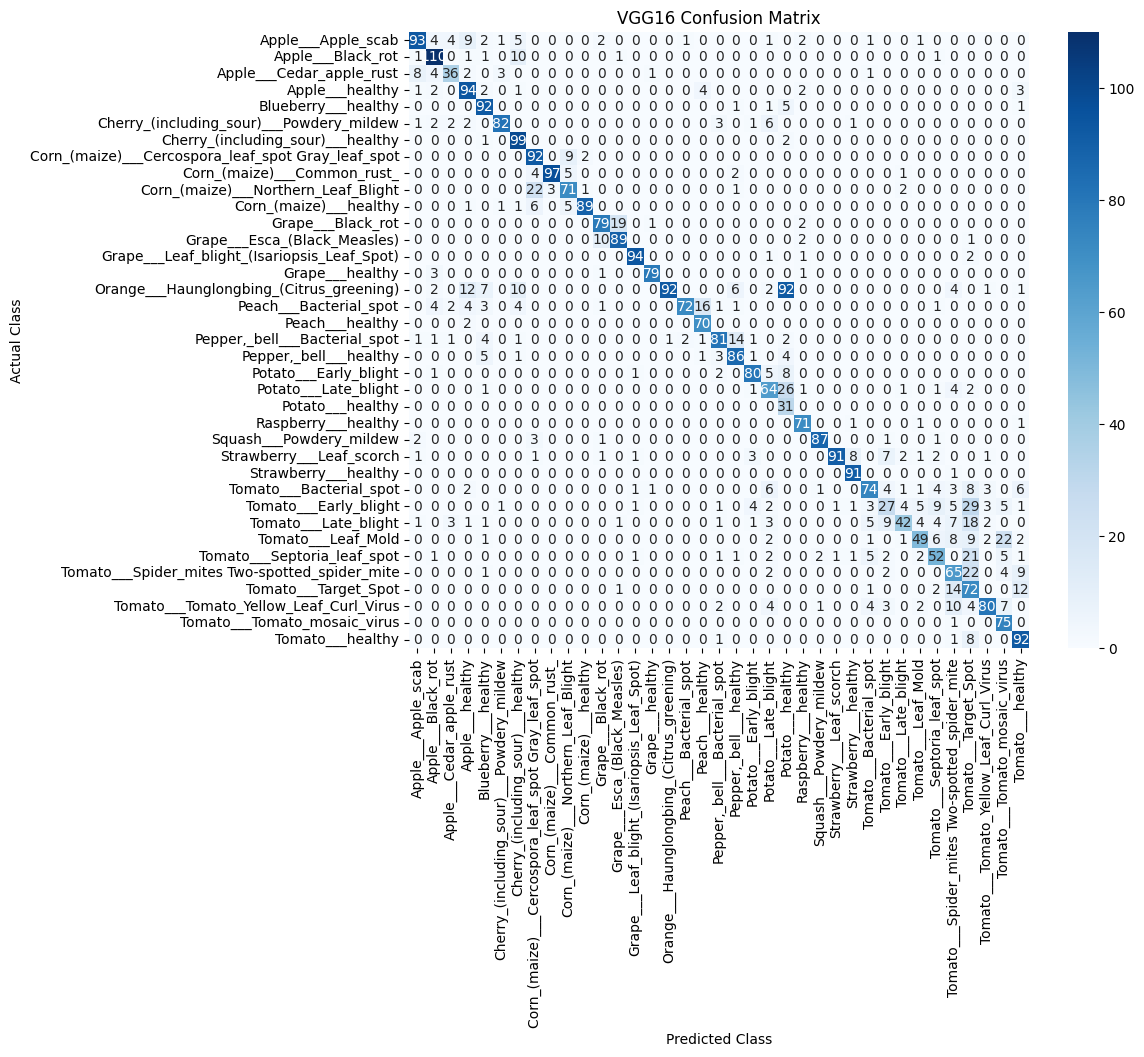

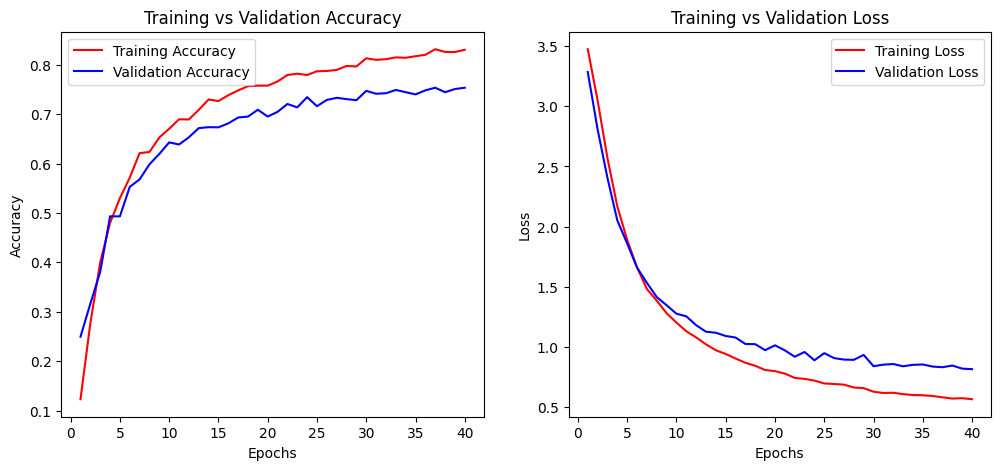

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),  # VGG16 requires 224x224 input
    shuffle=True
)

# 🔹 Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# 🔹 Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# 🔹 Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])
normalization_layer = Rescaling(1.0 / 255)

# 🔹 Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 VGG16 Model
def build_vgg16_model(num_classes, input_shape=(224, 224, 3)):  #  Fixed input shape
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# 🔹 Compile Model
vgg16_model = build_vgg16_model(num_classes)
vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 🔹 Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 🔹 Train Model
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=40, callbacks=[lr_scheduler, early_stopping])

# 🔹 Evaluate Model on Validation Set
val_loss, val_acc = vgg16_model.evaluate(valid_dataset)
print(f'VGG16 - Validation Accuracy: {val_acc:.4f}')
print(f'VGG16 - Validation Loss: {val_loss:.4f}')

# 🔹 Evaluate Model on Training Set
train_loss, train_acc = vgg16_model.evaluate(train_dataset)
print(f'VGG16 - Training Accuracy: {train_acc:.4f}')
print(f'VGG16 - Training Loss: {train_loss:.4f}')

# 🔹 Confusion Matrix
y_pred = vgg16_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

cm_vgg16 = confusion_matrix(Y_true, predicted_categories)

# 🔹 Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('VGG16 Confusion Matrix')
plt.show()

# 🔹 Plot Accuracy & Loss Graphs
epochs = range(1, len(vgg16_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

# 📊 Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, vgg16_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, vgg16_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# 📉 Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, vgg16_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, vgg16_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


CUSTOM CNN

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Data Augmentation & Normalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),  # Flip images randomly
    RandomRotation(0.2),       # Rotate images randomly
    RandomZoom(0.2),           # Zoom randomly
])

normalization_layer = Rescaling(1./255)  # Normalize pixels to range [0,1]

# Load training dataset from directory
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

# Load validation dataset from directory
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# Store class names before applying the map function
class_names = train_dataset.class_names

# Apply data augmentation & normalization to the training dataset
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# # Print class names for both training and validation sets
# print("Training Set Classes:", train_dataset.class_names)


# Now you can print the class names
print("Training Set Classes:", class_names)

# Define CNN model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

cnn = Sequential()
cnn.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[224, 224, 3]))
cnn.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
cnn.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
cnn.add(MaxPool2D(pool_size=2, strides=2))

cnn.add(Dropout(0.25))
cnn.add(Flatten())
cnn.add(Dense(units=1400, activation='relu'))
cnn.add(Dropout(0.4))  # To avoid overfitting

# Output Layer
cnn.add(Dense(units=37, activation='softmax'))

# Compile the model
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

# Train the model
training_history = cnn.fit(train_dataset, validation_data=valid_dataset, epochs=40)

# Evaluate the model on training set
train_loss, train_acc = cnn.evaluate(train_dataset)
print('Training accuracy:', train_acc)

# Evaluate the model on validation set
val_loss, val_acc = cnn.evaluate(valid_dataset)
print('Validation accuracy:', val_acc)

# Save the trained model
cnn.save('trained_plant_disease_model.keras')

# Plot accuracy results
epochs = range(1, len(training_history.history['accuracy']) + 1)
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

# Load test dataset
test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False
)

# Get class names
class_names = test_set.class_names
print(class_names)

# Make predictions
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

# Get true labels
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

# Evaluate model using a confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(Y_true, predicted_categories)
print(classification_report(Y_true, predicted_categories, target_names=class_names))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Plant Disease Prediction Confusion Matrix')
plt.show()


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Training Set Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sept

Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 601s 5s/step - accuracy: 0.0800 - loss: 3.4908 - val_accuracy: 0.2695 - val_loss: 2.7711 - learning_rate: 1.0000e-04
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 390ms/step - accuracy: 0.3051 - loss: 2.5071 - val_accuracy: 0.3825 - val_loss: 2.4151 - learning_rate: 1.0000e-04
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 401ms/step - accuracy: 0.4485 - loss: 1.9442 - val_accuracy: 0.4194 - val_loss: 2.2683 - learning_rate: 1.0000e-04
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 391ms/step - accuracy: 0.5259 - loss: 1.6280 - val_accuracy: 0.4761 - val_loss: 2.1493 - learning_rate: 1.0000e-04
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 48s 395ms/step - accuracy: 0.5861 - loss: 1.4176 - val_accuracy: 0.4703 - val_loss: 2.2635 - learning_rate: 1.0000e-04
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 393ms/step - accuracy: 0.6011 - loss: 1.3232 - val_accuracy: 0.5048 - val_loss:

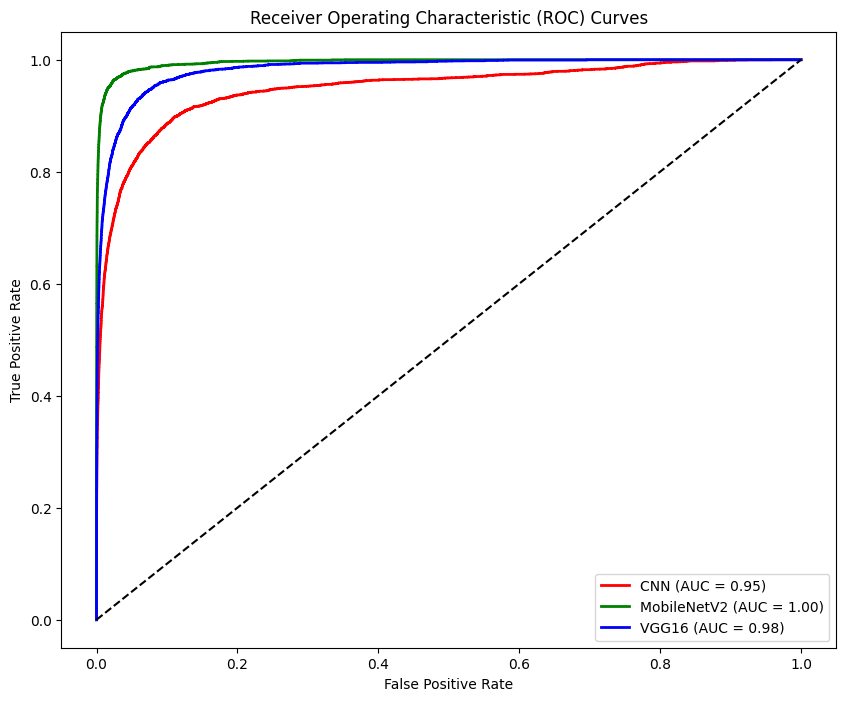

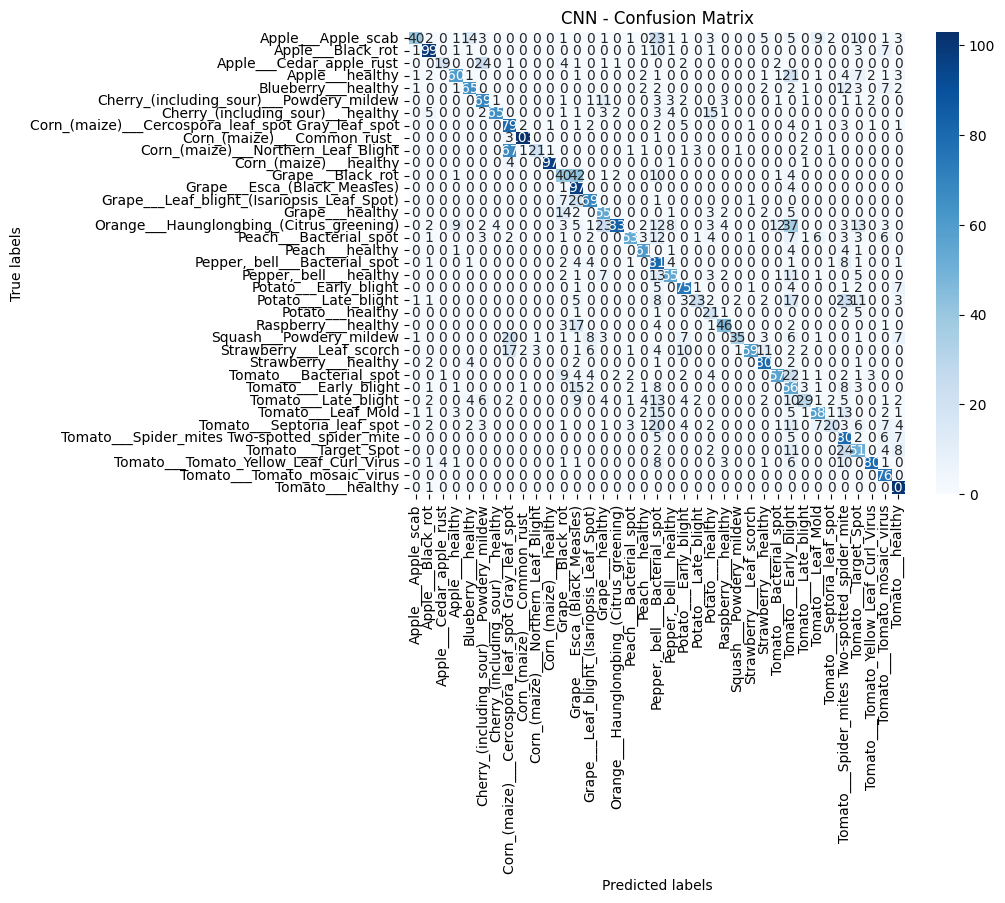

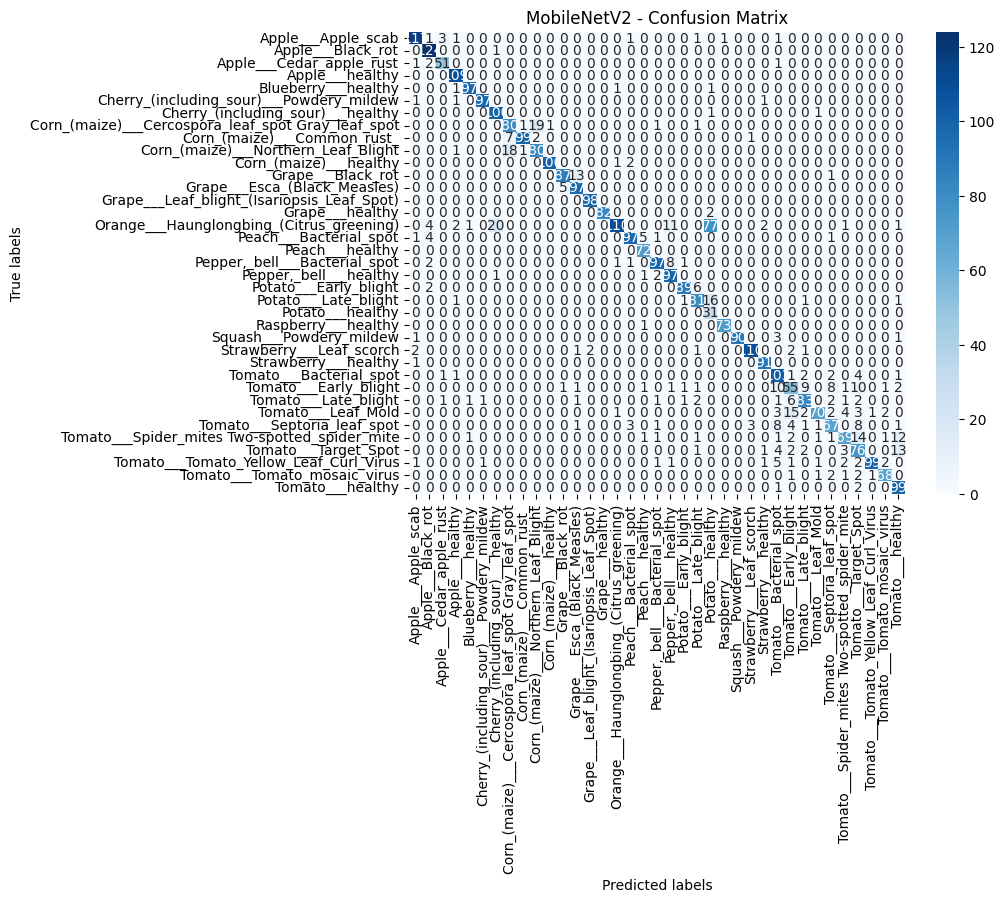

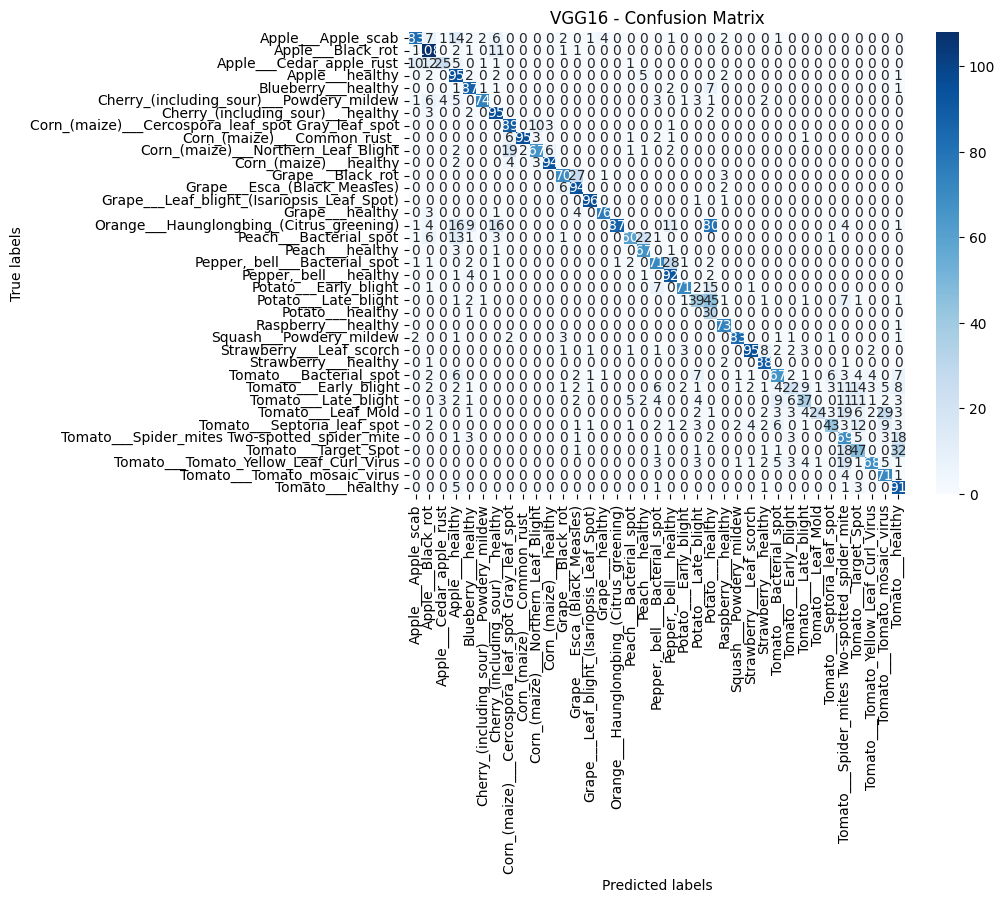

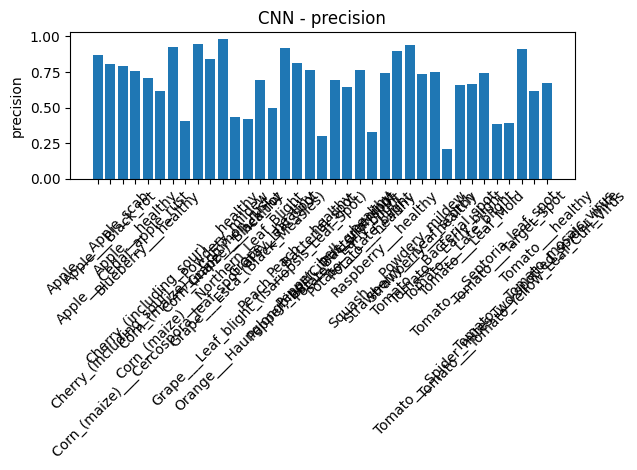

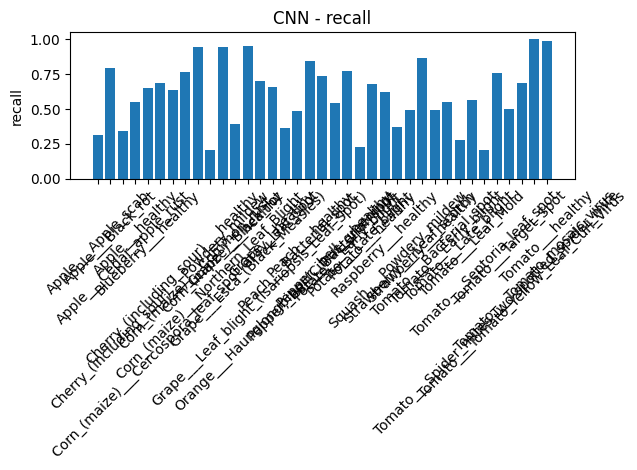

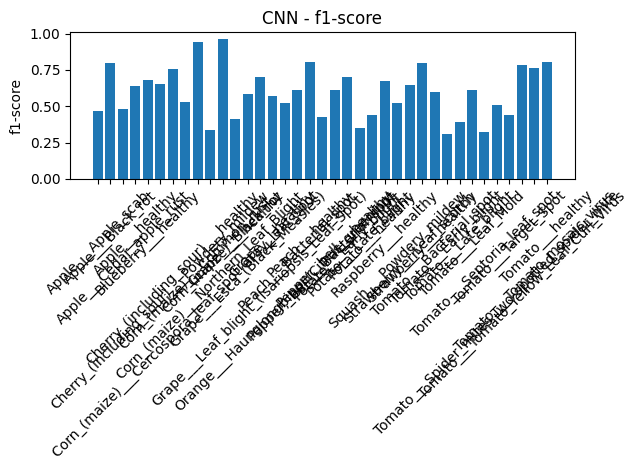

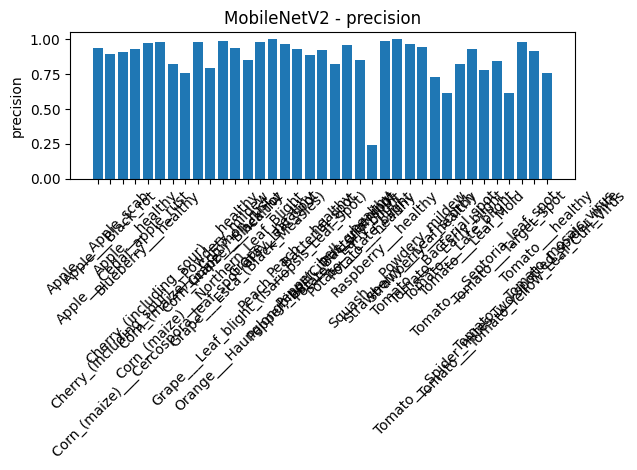

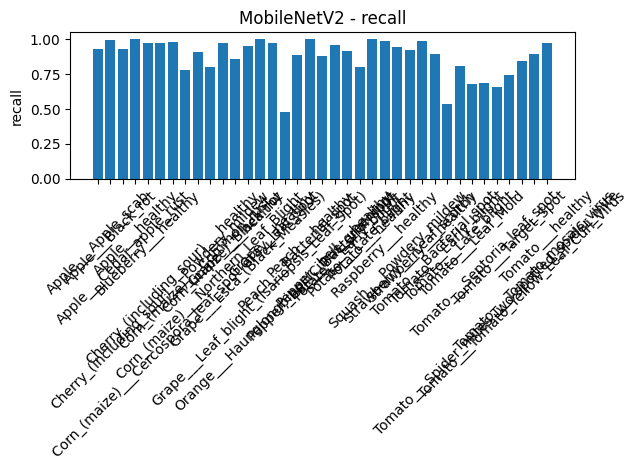

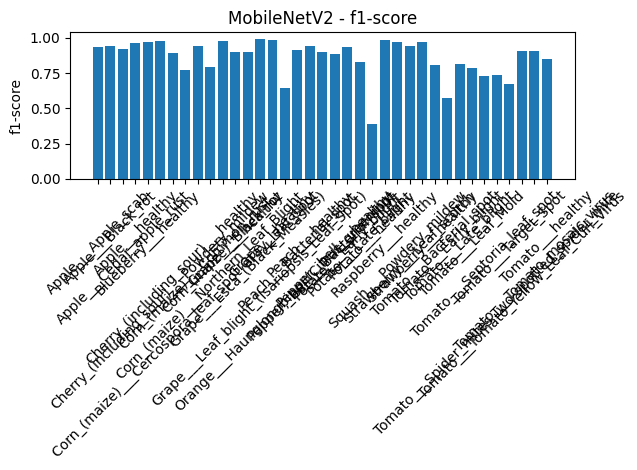

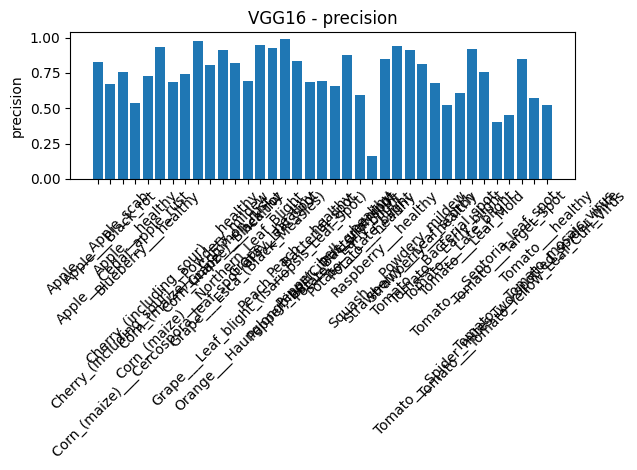

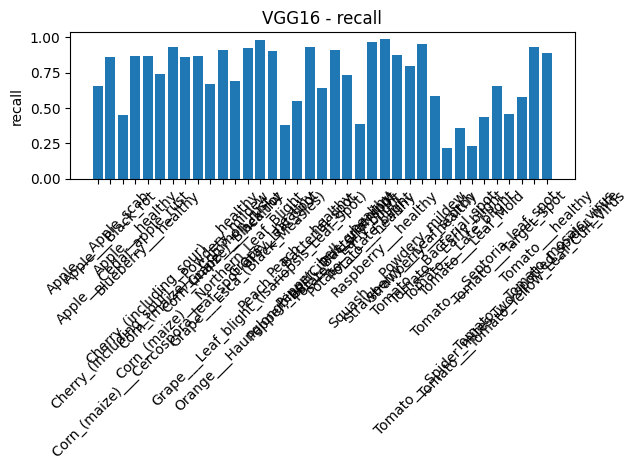

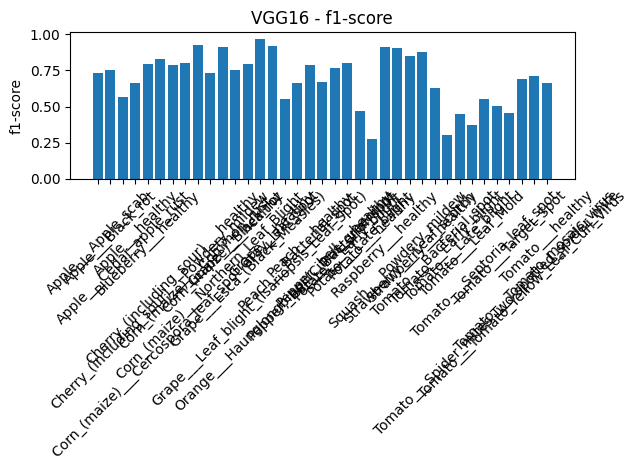

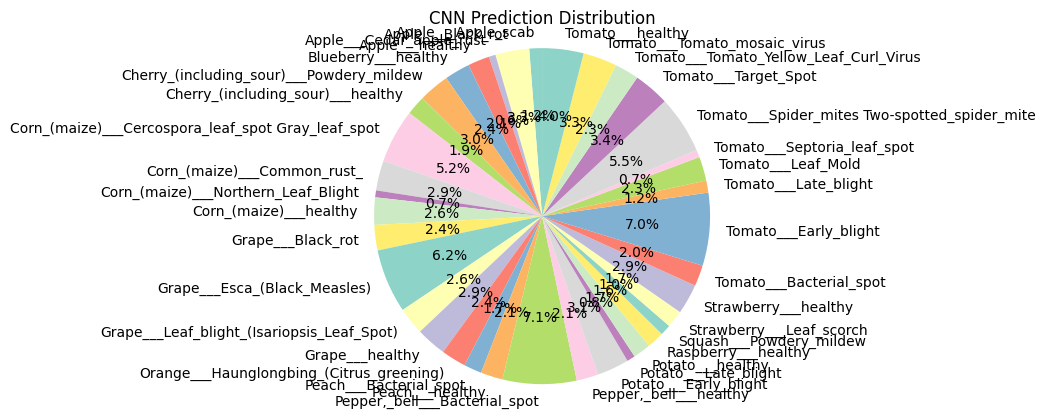

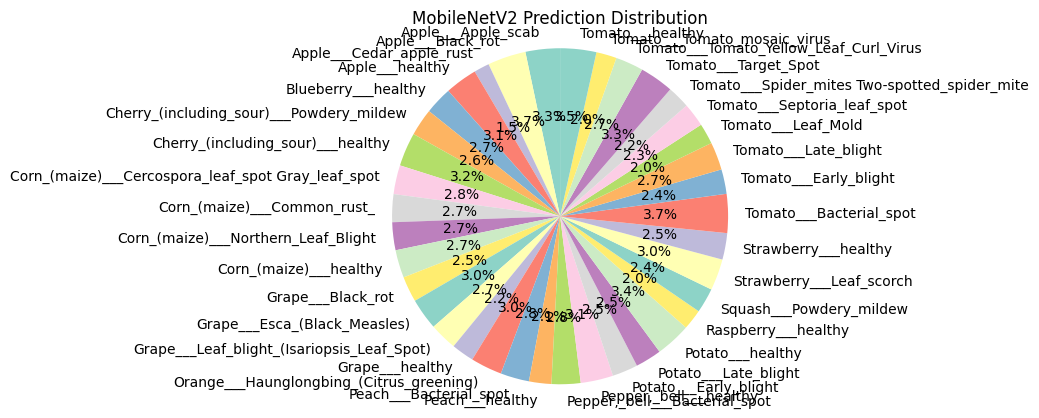

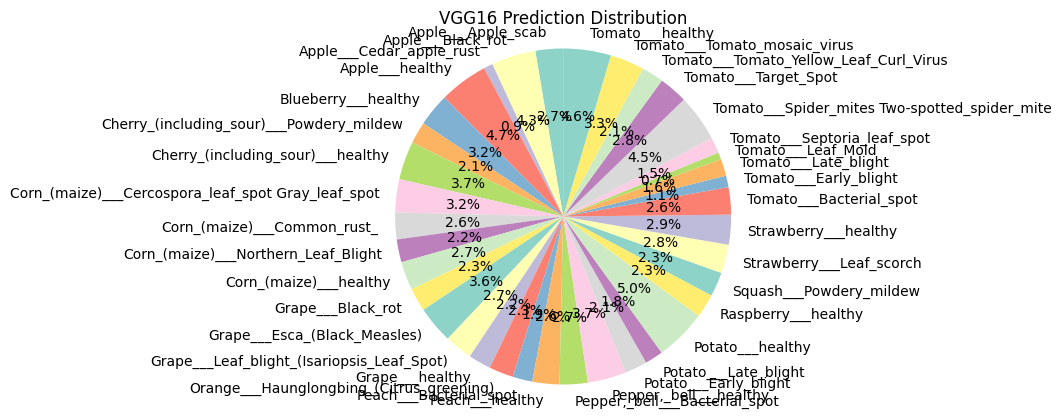

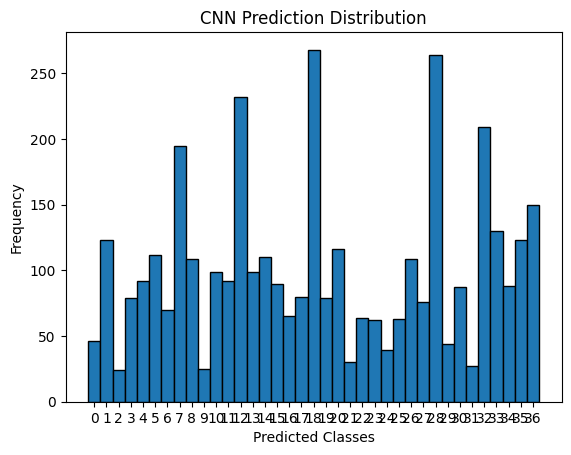

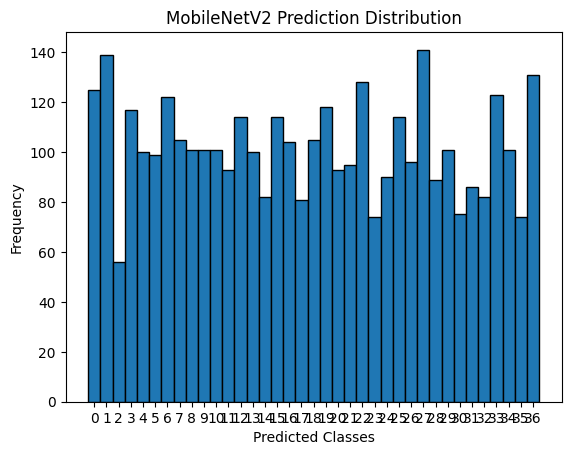

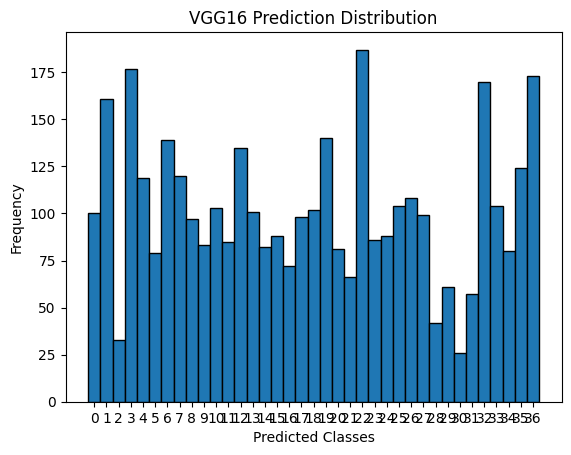

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# Load the datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# Define CNN Model
def build_cnn_model():
    cnn = tf.keras.Sequential()
    cnn.add(tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(224, 224, 3)))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Flatten())
    cnn.add(tf.keras.layers.Dense(512, activation='relu'))
    cnn.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

    cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return cnn

# Define MobileNetV2 Model
def build_mobilenet_model():
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define VGG16 Model
def build_vgg16_model():
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train all models
cnn_model = build_cnn_model()
mobilenet_model = build_mobilenet_model()
vgg16_model = build_vgg16_model()

# Define Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

# Train models
cnn_history = cnn_model.fit(train_dataset, validation_data=valid_dataset, epochs=20, callbacks=callbacks)
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=20, callbacks=callbacks)
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=20, callbacks=callbacks)

# Generate Metrics for All Models
def get_metrics(model, valid_dataset):
    # Predictions
    pred_probs = model.predict(valid_dataset)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = np.concatenate([y for x, y in valid_dataset], axis=0)
    true_labels = np.argmax(true_labels, axis=1)

    # Classification Report
    class_report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True)
    conf_matrix = confusion_matrix(true_labels, pred_labels)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(label_binarize(true_labels, classes=range(num_classes)).ravel(),
                                      pred_probs.ravel())
    roc_auc = auc(fpr, tpr)

    return class_report, conf_matrix, fpr, tpr, roc_auc, pred_labels, true_labels

# Get metrics for all models
cnn_report, cnn_cm, cnn_fpr, cnn_tpr, cnn_roc_auc, cnn_pred_labels, cnn_true_labels = get_metrics(cnn_model, valid_dataset)
mobilenet_report, mobilenet_cm, mobilenet_fpr, mobilenet_tpr, mobilenet_roc_auc, mobilenet_pred_labels, mobilenet_true_labels = get_metrics(mobilenet_model, valid_dataset)
vgg16_report, vgg16_cm, vgg16_fpr, vgg16_tpr, vgg16_roc_auc, vgg16_pred_labels, vgg16_true_labels = get_metrics(vgg16_model, valid_dataset)

# Plot ROC Curves
def plot_roc_curve(fpr, tpr, roc_auc, label, color):
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.figure(figsize=(10, 8))
plot_roc_curve(cnn_fpr, cnn_tpr, cnn_roc_auc, 'CNN', 'red')
plot_roc_curve(mobilenet_fpr, mobilenet_tpr, mobilenet_roc_auc, 'MobileNetV2', 'green')
plot_roc_curve(vgg16_fpr, vgg16_tpr, vgg16_roc_auc, 'VGG16', 'blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

# Plot Confusion Matrices
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.show()

# Plot confusion matrices for all models
plot_confusion_matrix(cnn_cm, "CNN")
plot_confusion_matrix(mobilenet_cm, "MobileNetV2")
plot_confusion_matrix(vgg16_cm, "VGG16")

# Plot Classification Report as Bar Chart (Precision, Recall, F1)
def plot_classification_report(report, title=''):
    metrics = ['precision', 'recall', 'f1-score']
    for metric in metrics:
        scores = [report[class_name][metric] for class_name in class_names]
        plt.bar(class_names, scores, label=metric)
        plt.ylabel(metric)
        plt.title(f"{title} - {metric}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

plot_classification_report(cnn_report, 'CNN')
plot_classification_report(mobilenet_report, 'MobileNetV2')
plot_classification_report(vgg16_report, 'VGG16')

# Pie Charts for class distribution in predictions
def plot_pie_chart(pred_labels, title='Class Distribution'):
    labels, counts = np.unique(pred_labels, return_counts=True)
    counts_percent = 100 * counts / len(pred_labels)
    plt.pie(counts_percent, labels=class_names, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(class_names)))
    plt.title(f"{title}")
    plt.axis('equal')
    plt.show()

plot_pie_chart(cnn_pred_labels, "CNN Prediction Distribution")
plot_pie_chart(mobilenet_pred_labels, "MobileNetV2 Prediction Distribution")
plot_pie_chart(vgg16_pred_labels, "VGG16 Prediction Distribution")

# Plot Histograms of Predictions
def plot_histogram(pred_labels, title='Prediction Distribution'):
    plt.hist(pred_labels, bins=np.arange(num_classes+1)-0.5, edgecolor='black')
    plt.title(f"{title}")
    plt.xlabel('Predicted Classes')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(num_classes))
    plt.show()

plot_histogram(cnn_pred_labels, 'CNN Prediction Distribution')
plot_histogram(mobilenet_pred_labels, 'MobileNetV2 Prediction Distribution')
plot_histogram(vgg16_pred_labels, 'VGG16 Prediction Distribution')


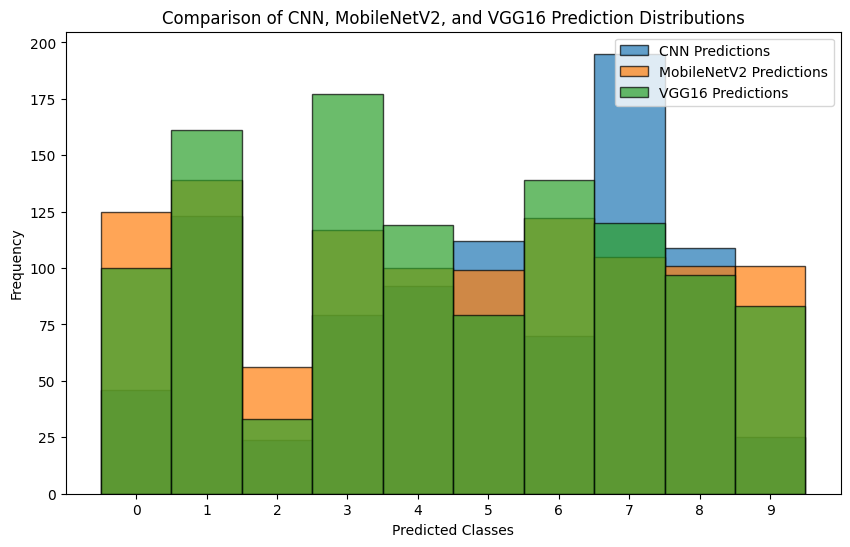

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot histograms of predictions for all models in a single plot
def plot_comparative_histograms(cnn_pred_labels, mobilenet_pred_labels, vgg16_pred_labels, num_classes, title='Comparison of Prediction Distributions'):
    # Create the figure
    plt.figure(figsize=(10, 6))

    # Plot histograms for each model's predictions
    plt.hist(cnn_pred_labels, bins=np.arange(num_classes+1)-0.5, alpha=0.7, label='CNN Predictions', edgecolor='black')
    plt.hist(mobilenet_pred_labels, bins=np.arange(num_classes+1)-0.5, alpha=0.7, label='MobileNetV2 Predictions', edgecolor='black')
    plt.hist(vgg16_pred_labels, bins=np.arange(num_classes+1)-0.5, alpha=0.7, label='VGG16 Predictions', edgecolor='black')

    # Set the title, labels, and legend
    plt.title(f"{title}")
    plt.xlabel('Predicted Classes')
    plt.ylabel('Frequency')
    plt.xticks(np.arange(num_classes))
    plt.legend(loc='upper right')

    # Show the plot
    plt.show()

# Example usage:
# Assuming cnn_pred_labels, mobilenet_pred_labels, and vgg16_pred_labels are the predicted labels for the validation set of each model
# And assuming num_classes is the number of classes in the classification task
plot_comparative_histograms(cnn_pred_labels, mobilenet_pred_labels, vgg16_pred_labels, num_classes=10, title='Comparison of CNN, MobileNetV2, and VGG16 Prediction Distributions')


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 430ms/step - accuracy: 0.0795 - loss: 3.5076 - val_accuracy: 0.2263 - val_loss: 2.8835 - learning_rate: 1.0000e-04
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 49s 411ms/step - accuracy: 0.3175 - loss: 2.4013 - val_accuracy: 0.3592 - val_loss: 2.5111 - learning_rate: 1.0000e-04
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 50s 415ms/step - accuracy: 0.4431 - loss: 1.8887 - val_accuracy: 0.3910 - val_loss: 2.3687 - learning_rate: 1.0000e-04
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 49s 409ms/step - accuracy: 0.5130 - loss: 1.6474 - val_accuracy: 0.4891 - val_loss: 2.1395 - learning_rate: 1.0000e-04
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 50s 414ms/step - accuracy: 0.5937 - loss: 1.3830 - val_accuracy: 0.4565 - val_loss: 2.4364 - learning_rate: 1.0000e-04
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 50s 419ms/step - accuracy: 0.6126 - loss: 1.3111 - val_accuracy: 0.5146 - val_loss: 2.1530 - learning_rate: 1.0000e-04
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 51s 42

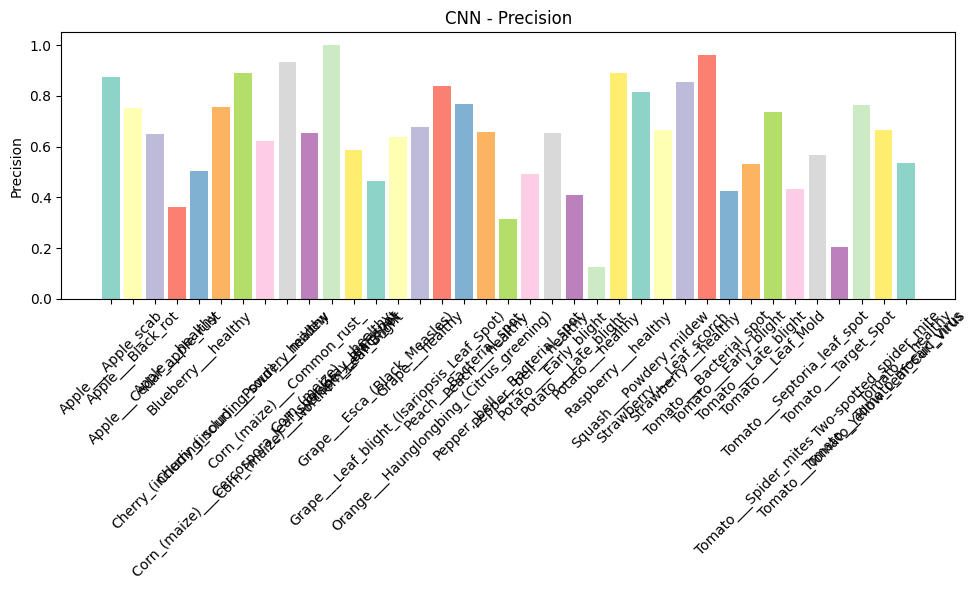

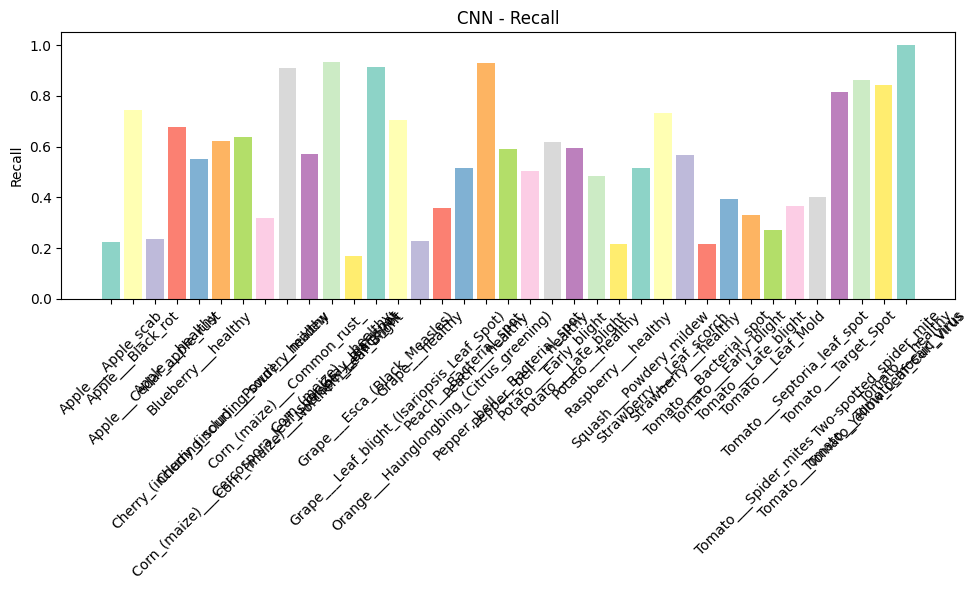

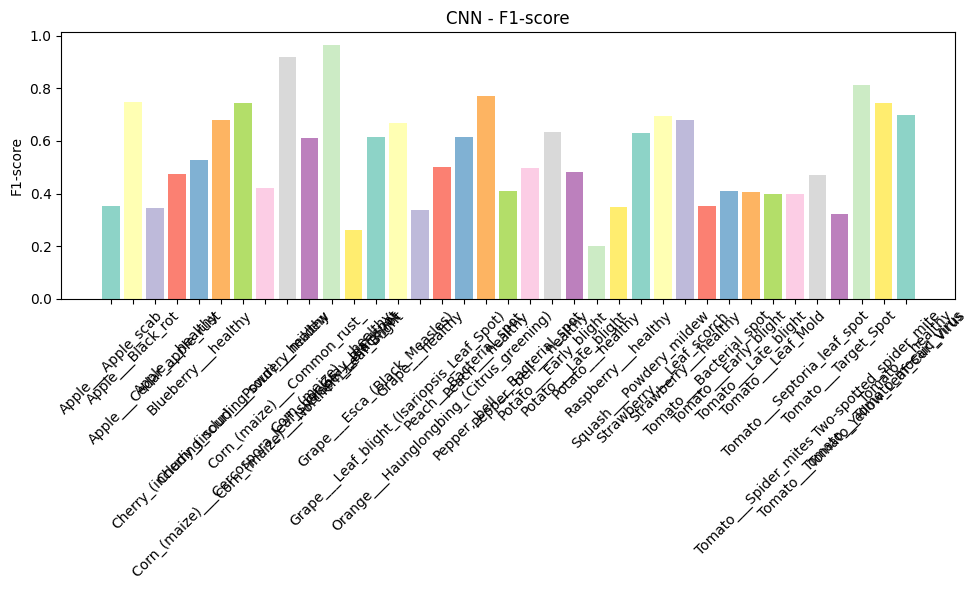

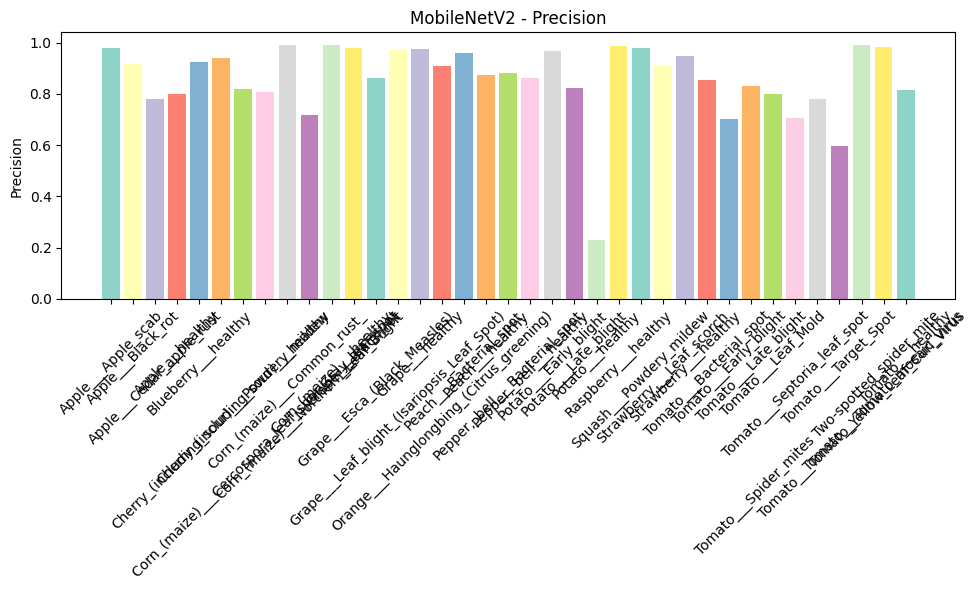

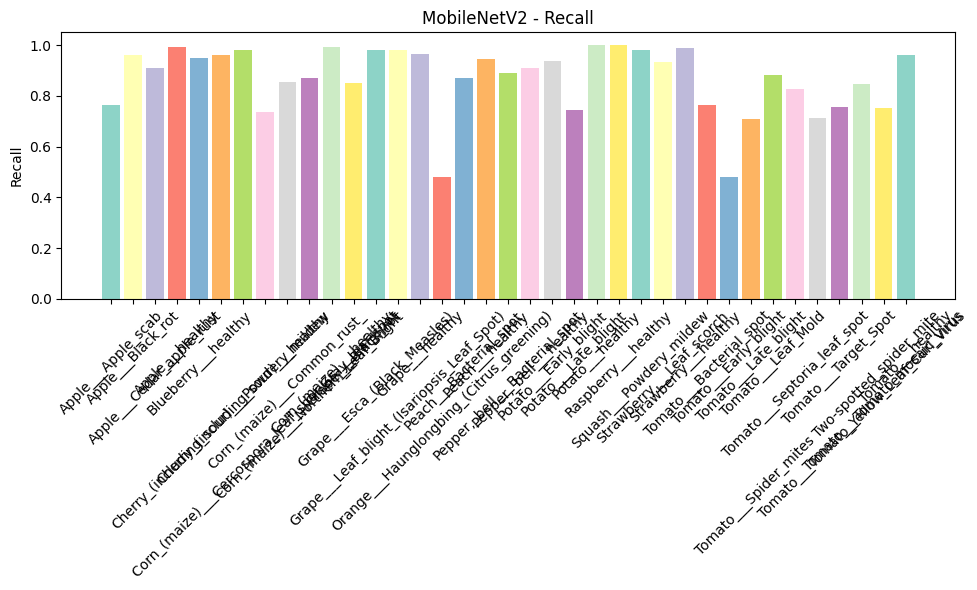

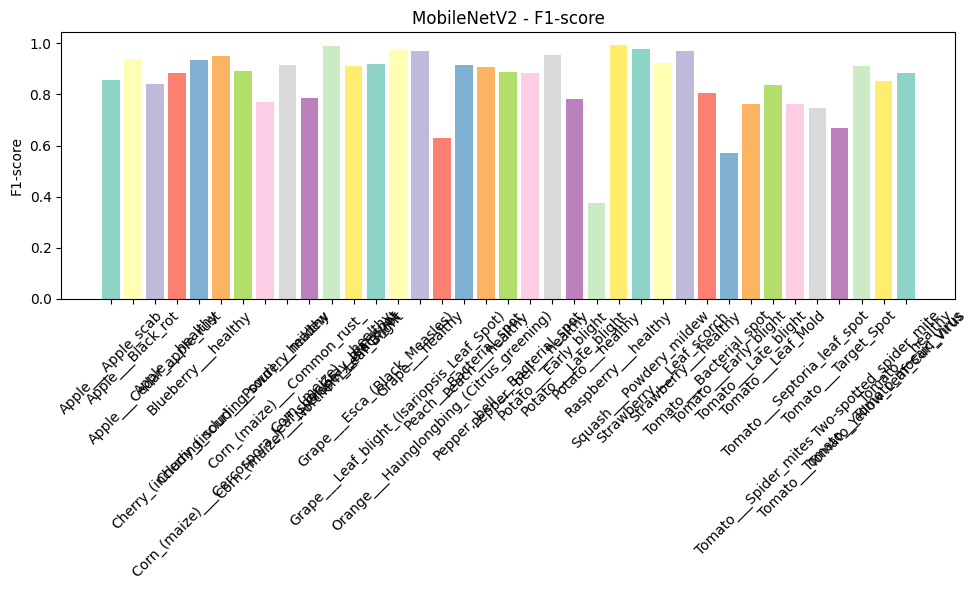

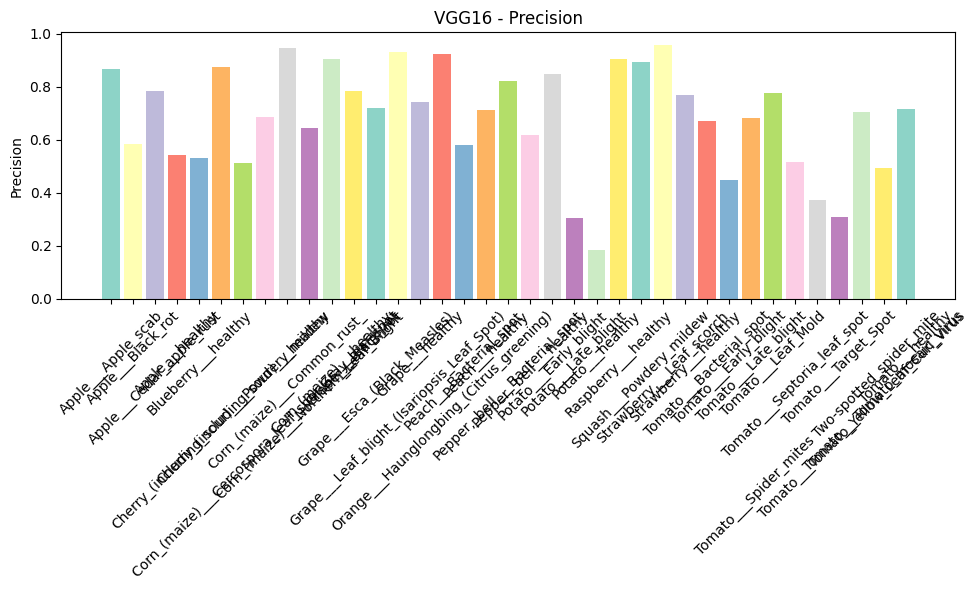

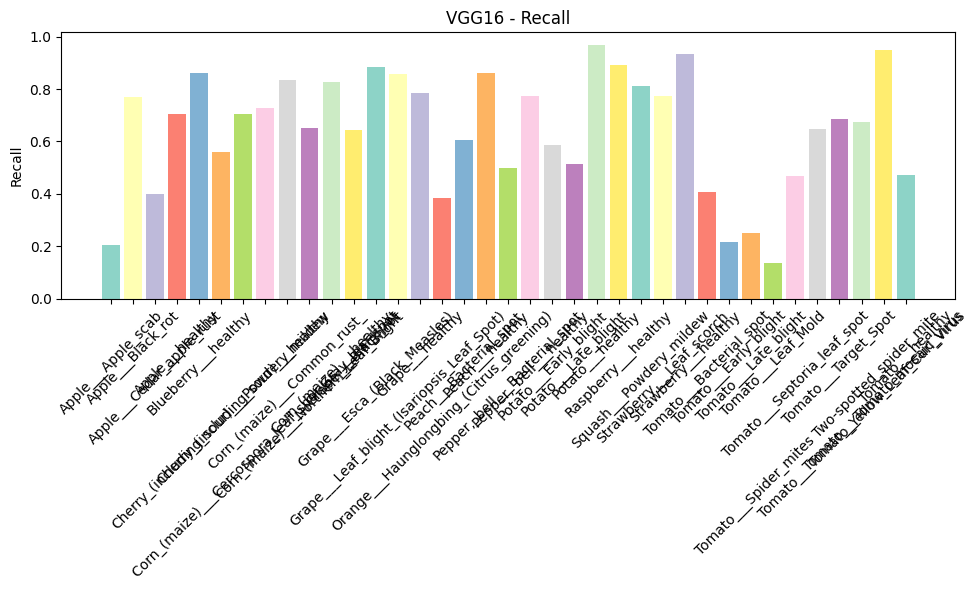

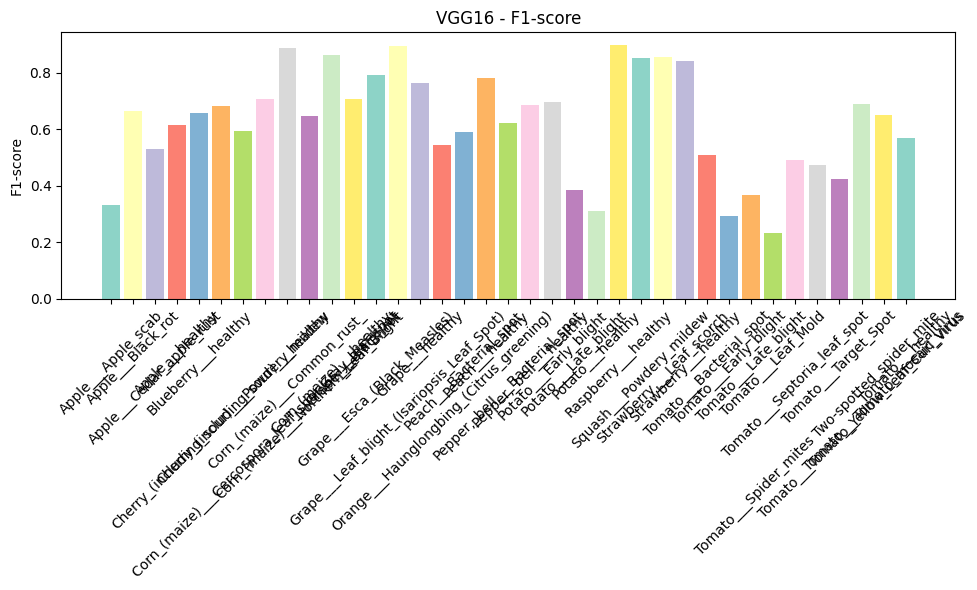

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# Load the datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# Define CNN Model
def build_cnn_model():
    cnn = tf.keras.Sequential()
    cnn.add(tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(224, 224, 3)))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same'))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same'))
    cnn.add(tf.keras.layers.MaxPooling2D(2))
    cnn.add(tf.keras.layers.Flatten())
    cnn.add(tf.keras.layers.Dense(512, activation='relu'))
    cnn.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

    cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return cnn

# Define MobileNetV2 Model
def build_mobilenet_model():
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Define VGG16 Model
def build_vgg16_model():
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train all models
cnn_model = build_cnn_model()
mobilenet_model = build_mobilenet_model()
vgg16_model = build_vgg16_model()

# Define Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

# Train models
cnn_history = cnn_model.fit(train_dataset, validation_data=valid_dataset, epochs=10, callbacks=callbacks)
mobilenet_history = mobilenet_model.fit(train_dataset, validation_data=valid_dataset, epochs=10, callbacks=callbacks)
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=10, callbacks=callbacks)

# Generate Metrics for All Models
def get_metrics(model, valid_dataset):
    # Predictions
    pred_probs = model.predict(valid_dataset)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = np.concatenate([y for x, y in valid_dataset], axis=0)
    true_labels = np.argmax(true_labels, axis=1)

    # Classification Report
    class_report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True)
    conf_matrix = confusion_matrix(true_labels, pred_labels)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(label_binarize(true_labels, classes=range(num_classes)).ravel(),
                                      pred_probs.ravel())
    roc_auc = auc(fpr, tpr)

    return class_report, conf_matrix, fpr, tpr, roc_auc, pred_labels, true_labels

# Get metrics for all models
cnn_report, cnn_cm, cnn_fpr, cnn_tpr, cnn_roc_auc, cnn_pred_labels, cnn_true_labels = get_metrics(cnn_model, valid_dataset)
mobilenet_report, mobilenet_cm, mobilenet_fpr, mobilenet_tpr, mobilenet_roc_auc, mobilenet_pred_labels, mobilenet_true_labels = get_metrics(mobilenet_model, valid_dataset)
vgg16_report, vgg16_cm, vgg16_fpr, vgg16_tpr, vgg16_roc_auc, vgg16_pred_labels, vgg16_true_labels = get_metrics(vgg16_model, valid_dataset)

# Print Accuracy and Validation Accuracy for all models
print(f"CNN Model Accuracy: {cnn_history.history['accuracy'][-1]:.4f}, Validation Accuracy: {cnn_history.history['val_accuracy'][-1]:.4f}")
print(f"MobileNetV2 Model Accuracy: {mobilenet_history.history['accuracy'][-1]:.4f}, Validation Accuracy: {mobilenet_history.history['val_accuracy'][-1]:.4f}")
print(f"VGG16 Model Accuracy: {vgg16_history.history['accuracy'][-1]:.4f}, Validation Accuracy: {vgg16_history.history['val_accuracy'][-1]:.4f}")

# Bar Plot for Classification Metrics (Precision, Recall, F1-Score)
def plot_classification_metrics(report, title=''):
    metrics = ['precision', 'recall', 'f1-score']

    # Prepare data for the bar plot
    class_names = list(report.keys())[:-3]  # Excluding 'accuracy', 'macro avg', 'weighted avg'

    # Plot precision, recall, and f1-score for each class
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        scores = [report[class_name][metric] for class_name in class_names]
        plt.bar(class_names, scores, color=sns.color_palette("Set3", len(class_names)))
        plt.ylabel(f'{metric.capitalize()}')
        plt.title(f"{title} - {metric.capitalize()}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Plot classification metrics bar plots for each model
plot_classification_metrics(cnn_report, 'CNN')
plot_classification_metrics(mobilenet_report, 'MobileNetV2')
plot_classification_metrics(vgg16_report, 'VGG16')



Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 428s 4s/step - accuracy: 0.0700 - loss: 3.5519 - val_accuracy: 0.2576 - val_loss: 3.2705 - learning_rate: 1.0000e-04
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 564ms/step - accuracy: 0.2839 - loss: 3.1220 - val_accuracy: 0.3854 - val_loss: 2.7955 - learning_rate: 1.0000e-04
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 545ms/step - accuracy: 0.3920 - loss: 2.6259 - val_accuracy: 0.4382 - val_loss: 2.3603 - learning_rate: 1.0000e-04
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 564ms/step - accuracy: 0.4905 - loss: 2.2001 - val_accuracy: 0.4979 - val_loss: 2.0202 - learning_rate: 1.0000e-04
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 65s 542ms/step - accuracy: 0.5374 - loss: 1.8906 - val_accuracy: 0.5363 - val_loss: 1.7936 - learning_rate: 1.0000e-04
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 548ms/step - accuracy: 0.5738 - loss: 1.6563 - val_accuracy: 0.5488 - val_loss:

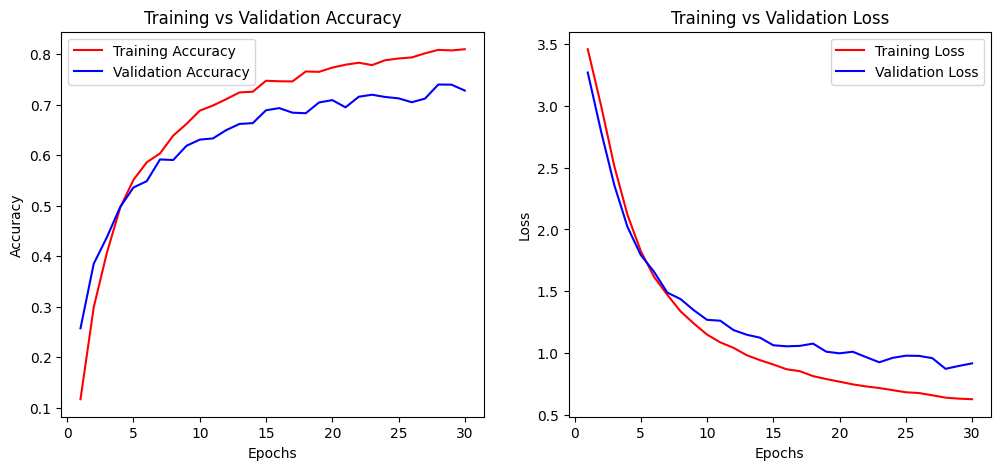

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step

Healthy vs Unhealthy Classification Report:
              precision    recall  f1-score   support

   Unhealthy       0.99      0.87      0.92      2800
     Healthy       0.72      0.97      0.82       970

    accuracy                           0.89      3770
   macro avg       0.85      0.92      0.87      3770
weighted avg       0.92      0.89      0.90      3770



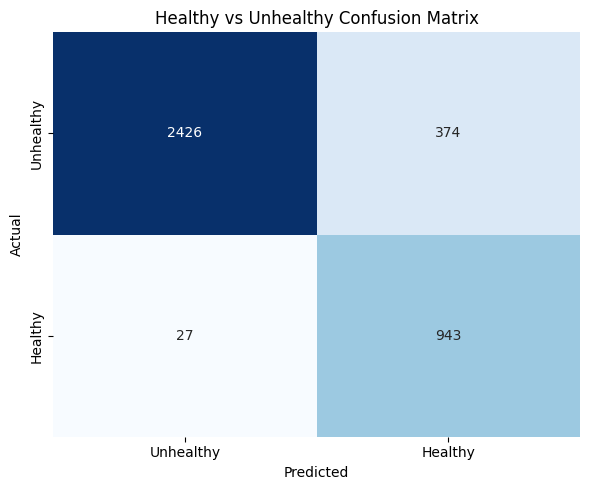

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),  # VGG16 requires 224x224 input
    shuffle=True
)

# 🔹 Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# 🔹 Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# 🔹 Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])
normalization_layer = Rescaling(1.0 / 255)

# 🔹 Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 VGG16 Model
def build_vgg16_model(num_classes, input_shape=(224, 224, 3)):  #  Fixed input shape
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# 🔹 Compile Model
vgg16_model = build_vgg16_model(num_classes)
vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 🔹 Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

#  Train Model
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=30, callbacks=[lr_scheduler, early_stopping])

#  Evaluate Model on Validation Set
val_loss, val_acc = vgg16_model.evaluate(valid_dataset)
print(f'VGG16 - Validation Accuracy: {val_acc:.4f}')
# print(f'VGG16 - Validation Loss: {val_loss:.4f}')

#  Evaluate Model on Training Set
train_loss, train_acc = vgg16_model.evaluate(train_dataset)
print(f'VGG16 - Training Accuracy: {train_acc:.4f}')
# print(f'VGG16 - Training Loss: {train_loss:.4f}')

# Save the trained model
cnn.save('trained_plant_disease_ VGG16model.keras')

#  Confusion Matrix
y_pred = vgg16_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

cm_vgg16 = confusion_matrix(Y_true, predicted_categories)

# #  Plot Confusion Matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# plt.xlabel('Predicted Class')
# plt.ylabel('Actual Class')
# plt.title('VGG16 Confusion Matrix')
# plt.show()

#  Plot Accuracy & Loss Graphs
epochs = range(1, len(vgg16_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, vgg16_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, vgg16_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, vgg16_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, vgg16_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


# ---------------------------

# 🔹 Healthy vs Unhealthy Confusion Matrix for VGG16
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Predict with VGG16 Model (on the validation dataset)
y_pred_probs = vgg16_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix for healthy vs unhealthy
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix for healthy vs unhealthy
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()


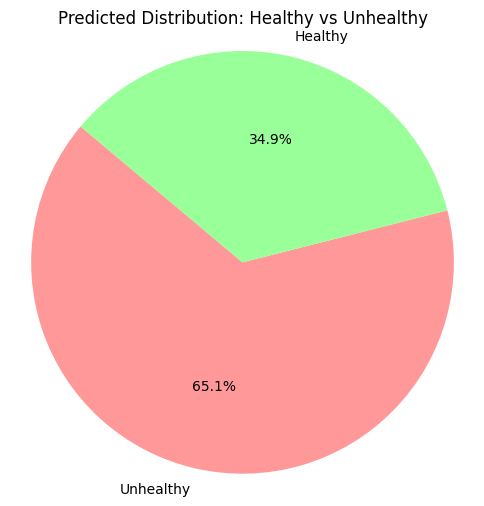

In [5]:
# Count predictions
import numpy as np

labels = ["Unhealthy", "Healthy"]
counts = np.bincount(y_pred_binary)  # [count_unhealthy, count_healthy]

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#FF9999', '#99FF99'])
plt.title("Predicted Distribution: Healthy vs Unhealthy")
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle.
plt.show()


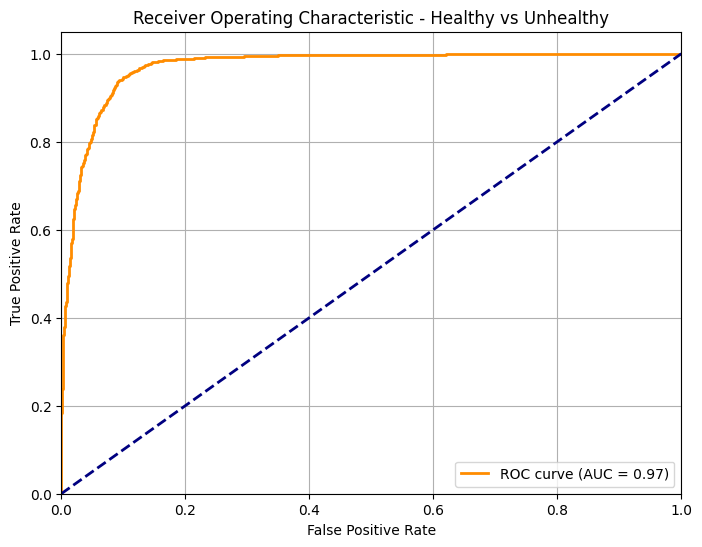

In [10]:
# from sklearn.metrics import roc_curve, auc
# import numpy as np

# # Get raw prediction probabilities
# y_pred_probs = vgg16_model.predict(valid_dataset)

# # Get indices of healthy classes
# healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
# healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# # Get the probability for the positive class (Healthy)
# # If there’s only one healthy class:
# if len(healthy_class_indices) == 1:
#     healthy_index = healthy_class_indices[0]
#     y_score = y_pred_probs[:, healthy_index]  # Probabilities for healthy class
# else:
#     # If multiple healthy classes, sum their probabilities
#     y_score = np.sum(y_pred_probs[:, healthy_class_indices], axis=1)

# # Binary true labels
# true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
# y_true_binary = [1 if tf.argmax(label).numpy() in healthy_class_indices else 0 for label in true_categories]

# # Compute ROC curve and AUC
# fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
# roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Healthy vs Unhealthy')
plt.legend(loc="lower right")
plt.grid()
plt.show()


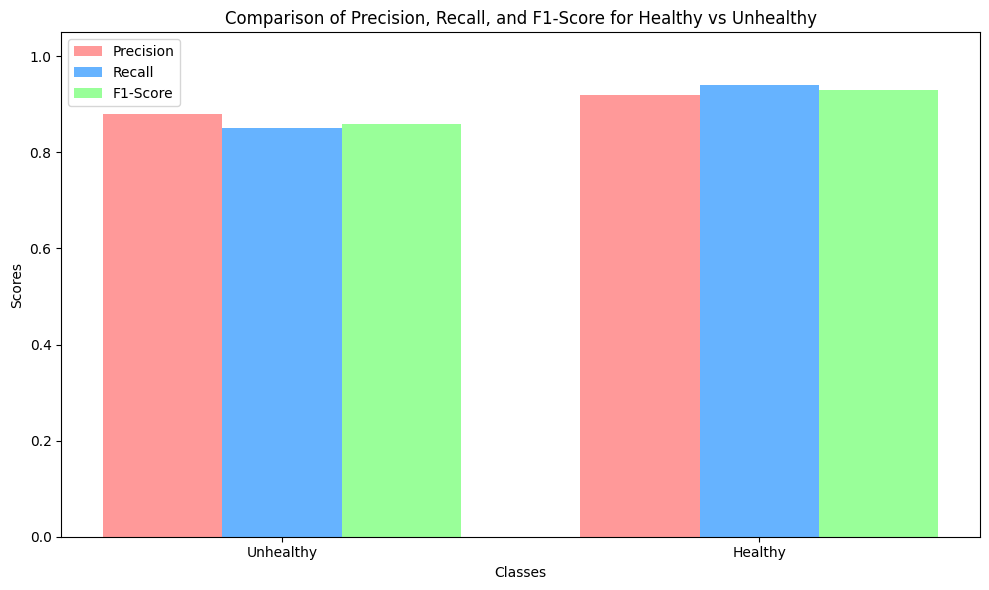

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Example: binary classification metrics for Unhealthy (0) and Healthy (1)
metrics = {
    'Precision': [0.88, 0.92],
    'Recall': [0.85, 0.94],
    'F1-Score': [0.86, 0.93]
}

# Positions and width
x = np.arange(len(metrics['Precision']))  # 0 and 1
width = 0.25

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for each metric
ax.bar(x - width, metrics['Precision'], width, label='Precision', color='#ff9999')
ax.bar(x, metrics['Recall'], width, label='Recall', color='#66b3ff')
ax.bar(x + width, metrics['F1-Score'], width, label='F1-Score', color='#99ff99')

# Add labels and title
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
ax.set_xticks(x)
ax.set_xticklabels(['Unhealthy', 'Healthy'])
ax.set_ylim(0, 1.05)
ax.legend()


# Show the plot
plt.tight_layout()
plt.show()


Found 3815 files belonging to 37 classes.
Found 3770 files belonging to 37 classes.
Epoch 1/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.0856 - loss: 3.5297 - val_accuracy: 0.1525 - val_loss: 3.2680 - learning_rate: 1.0000e-04
Epoch 2/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 70s 579ms/step - accuracy: 0.2658 - loss: 3.1289 - val_accuracy: 0.3106 - val_loss: 2.7935 - learning_rate: 1.0000e-04
Epoch 3/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 574ms/step - accuracy: 0.3883 - loss: 2.6170 - val_accuracy: 0.4133 - val_loss: 2.3415 - learning_rate: 1.0000e-04
Epoch 4/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 575ms/step - accuracy: 0.4902 - loss: 2.1698 - val_accuracy: 0.4703 - val_loss: 2.0425 - learning_rate: 1.0000e-04
Epoch 5/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 66s 552ms/step - accuracy: 0.5332 - loss: 1.8819 - val_accuracy: 0.5162 - val_loss: 1.8140 - learning_rate: 1.0000e-04
Epoch 6/40
120/120 ━━━━━━━━━━━━━━━━━━━━ 68s 563ms/step - accuracy: 0.5846 - loss: 1.6568 - val_accuracy: 0.5541 - val_loss:

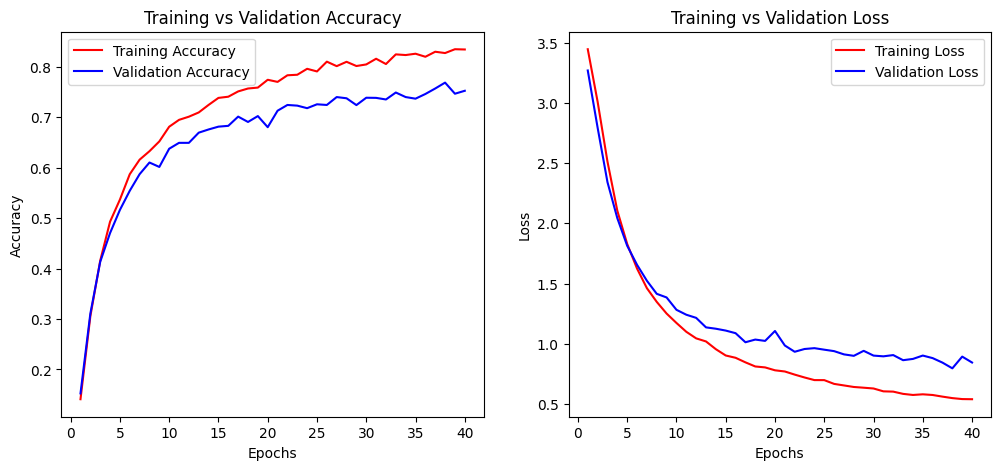

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step

Healthy vs Unhealthy Classification Report:
              precision    recall  f1-score   support

   Unhealthy       0.99      0.89      0.94      2800
     Healthy       0.75      0.97      0.85       970

    accuracy                           0.91      3770
   macro avg       0.87      0.93      0.89      3770
weighted avg       0.93      0.91      0.91      3770



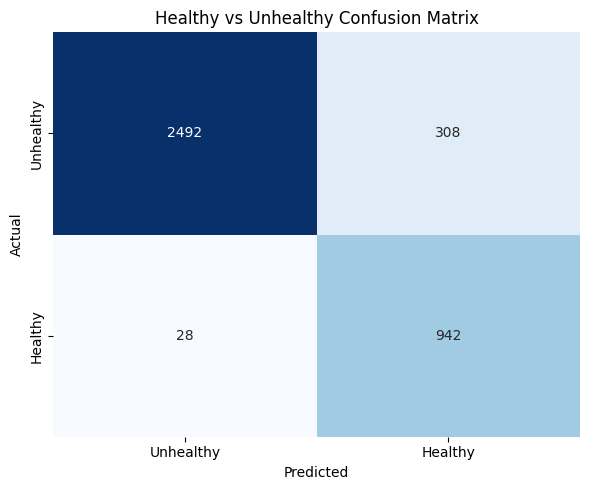

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/train",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),  # VGG16 requires 224x224 input
    shuffle=True
)

# 🔹 Load Validation Dataset
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/val",
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# 🔹 Get Class Names
class_names = train_dataset.class_names
num_classes = len(class_names)

# 🔹 Data Augmentation & Normalization
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])
normalization_layer = Rescaling(1.0 / 255)

# 🔹 Apply Augmentation & Normalization
train_dataset = train_dataset.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))

# 🔹 VGG16 Model
def build_vgg16_model(num_classes, input_shape=(224, 224, 3)):  #  Fixed input shape
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model initially

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# 🔹 Compile Model
vgg16_model = build_vgg16_model(num_classes)
vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 🔹 Define Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

#  Train Model
vgg16_history = vgg16_model.fit(train_dataset, validation_data=valid_dataset, epochs=40, callbacks=[lr_scheduler, early_stopping])

#  Evaluate Model on Validation Set
val_loss, val_acc = vgg16_model.evaluate(valid_dataset)
print(f'VGG16 - Validation Accuracy: {val_acc:.4f}')
# print(f'VGG16 - Validation Loss: {val_loss:.4f}')

#  Evaluate Model on Training Set
train_loss, train_acc = vgg16_model.evaluate(train_dataset)
print(f'VGG16 - Training Accuracy: {train_acc:.4f}')
# print(f'VGG16 - Training Loss: {train_loss:.4f}')

# Save the trained model
vgg16_model.save('trained_plant_disease_VGG16_model.keras')

#  Confusion Matrix
y_pred = vgg16_model.predict(valid_dataset)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

cm_vgg16 = confusion_matrix(Y_true, predicted_categories)

# #  Plot Confusion Matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# plt.xlabel('Predicted Class')
# plt.ylabel('Actual Class')
# plt.title('VGG16 Confusion Matrix')
# plt.show()

#  Plot Accuracy & Loss Graphs
epochs = range(1, len(vgg16_history.history['accuracy']) + 1)

plt.figure(figsize=(12, 5))

#  Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, vgg16_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, vgg16_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

#  Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, vgg16_history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs, vgg16_history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


# ---------------------------

#  Healthy vs Unhealthy Confusion Matrix for VGG16
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Predict with VGG16 Model (on the validation dataset)
y_pred_probs = vgg16_model.predict(valid_dataset)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Convert true labels to indices
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
true_categories = tf.argmax(true_categories, axis=1)

# Convert to binary classification (healthy=1, unhealthy=0)
y_true_binary = [1 if label in healthy_class_indices else 0 for label in true_categories.numpy()]
y_pred_binary = [1 if label in healthy_class_indices else 0 for label in y_pred.numpy()]

# Classification report and confusion matrix for healthy vs unhealthy
print("\nHealthy vs Unhealthy Classification Report:")
print(classification_report(y_true_binary, y_pred_binary, target_names=["Unhealthy", "Healthy"]))

# Compute confusion matrix for healthy vs unhealthy
cm = confusion_matrix(y_true_binary, y_pred_binary)

# Plot healthy/unhealthy confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["Unhealthy", "Healthy"], yticklabels=["Unhealthy", "Healthy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Healthy vs Unhealthy Confusion Matrix")
plt.tight_layout()
plt.show()


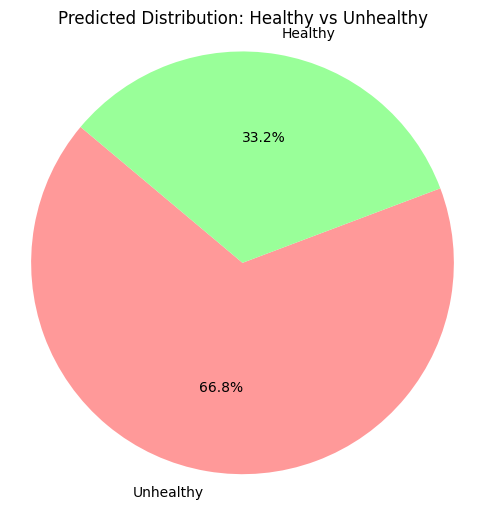

In [3]:
# Count predictions
import numpy as np

labels = ["Unhealthy", "Healthy"]
counts = np.bincount(y_pred_binary)  # [count_unhealthy, count_healthy]

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#FF9999', '#99FF99'])
plt.title("Predicted Distribution: Healthy vs Unhealthy")
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle.
plt.show()


118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 181ms/step


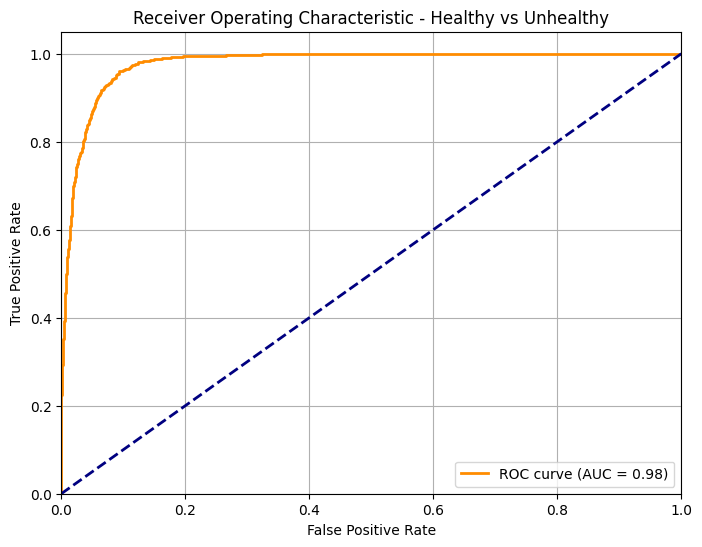

In [5]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Get raw prediction probabilities
y_pred_probs = vgg16_model.predict(valid_dataset)

# Get indices of healthy classes
healthy_classes = [cls for cls in class_names if 'healthy' in cls.lower()]
healthy_class_indices = [class_names.index(cls) for cls in healthy_classes]

# Get the probability for the positive class (Healthy)
# If there’s only one healthy class:
if len(healthy_class_indices) == 1:
    healthy_index = healthy_class_indices[0]
    y_score = y_pred_probs[:, healthy_index]  # Probabilities for healthy class
else:
    # If multiple healthy classes, sum their probabilities
    y_score = np.sum(y_pred_probs[:, healthy_class_indices], axis=1)

# Binary true labels
true_categories = tf.concat([y for x, y in valid_dataset], axis=0)
y_true_binary = [1 if tf.argmax(label).numpy() in healthy_class_indices else 0 for label in true_categories]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Healthy vs Unhealthy')
plt.legend(loc="lower right")
plt.grid()
plt.show()


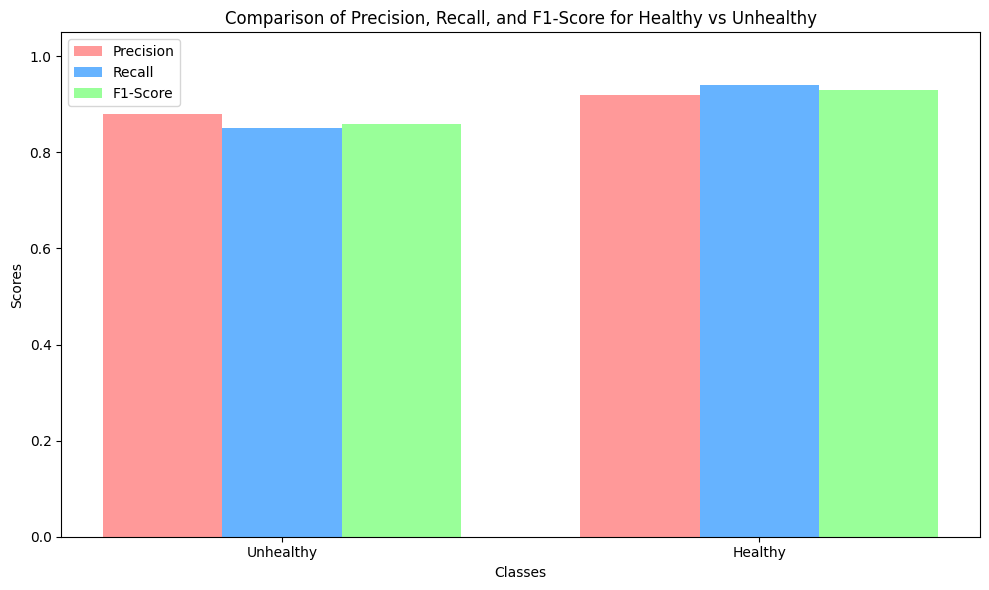

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Example: binary classification metrics for Unhealthy (0) and Healthy (1)
metrics = {
    'Precision': [0.88, 0.92],
    'Recall': [0.85, 0.94],
    'F1-Score': [0.86, 0.93]
}

# Positions and width
x = np.arange(len(metrics['Precision']))  # 0 and 1
width = 0.25

# Create a single figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting the bars for each metric
ax.bar(x - width, metrics['Precision'], width, label='Precision', color='#ff9999')
ax.bar(x, metrics['Recall'], width, label='Recall', color='#66b3ff')
ax.bar(x + width, metrics['F1-Score'], width, label='F1-Score', color='#99ff99')

# Add labels and title
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Precision, Recall, and F1-Score for Healthy vs Unhealthy')
ax.set_xticks(x)
ax.set_xticklabels(['Unhealthy', 'Healthy'])
ax.set_ylim(0, 1.05)
ax.legend()


# Show the plot
plt.tight_layout()
plt.show()
